<a href="https://colab.research.google.com/github/Sonalii06/stock-price-movement-predictor/blob/main/Stock_Price_Movement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Price Movement Predictor

### Time-Series Machine Learning

Predicting next-day market direction (Up/Down) using historical daily OHLCV data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Load Historical OHLCV Data

We use daily historical data for Apple Inc. (AAPL).

The dataset contains:
- Open
- High
- Low
- Close
- Volume

In [ ]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.232384,40.241728,39.531715,39.741918,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412216,40.514981,40.190339,40.297772,89738400
2018-01-05,40.872322,40.958737,40.416888,40.507975,94640000
2018-01-08,40.720520,41.014800,40.622423,40.720520,82271200


2018 ───────────────────────────── 2025
              -
       Historical Dataset

In [ ]:
print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (2011, 5)

Columns:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Data types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.232384,40.241728,39.531715,39.741918,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412216,40.514981,40.190339,40.297772,89738400
2018-01-05,40.872322,40.958737,40.416888,40.507975,94640000
2018-01-08,40.720520,41.014800,40.622423,40.720520,82271200


In [ ]:
# Remove the extra yfinance column level
data.columns = data.columns.get_level_values(0)

# Display the cleaned columns
print(data.columns)

data.head()

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232384,40.241728,39.531715,39.741918,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412216,40.514981,40.190339,40.297772,89738400
2018-01-05,40.872322,40.958737,40.416888,40.507975,94640000
2018-01-08,40.720520,41.014800,40.622423,40.720520,82271200


In [ ]:
print("Dataset shape:", data.shape)

print("\nDate range:")
print(data.index.min(), "to", data.index.max())

print("\nMissing values:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

Dataset shape: (2011, 5)

Date range:
2018-01-02 00:00:00 to 2025-12-31 00:00:00

Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Data types:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


## 2. Explore the Historical Data

Before creating the prediction target, we inspect the structure,
date range, and price/volume information in the dataset.

In [ ]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232384,40.241728,39.531715,39.741918,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412216,40.514981,40.190339,40.297772,89738400
2018-01-05,40.872322,40.958737,40.416888,40.507975,94640000
2018-01-08,40.720520,41.014800,40.622423,40.720520,82271200
2018-01-09,40.715836,40.886331,40.500964,40.767218,86336000
2018-01-10,40.706497,40.708835,40.405211,40.442581,95839600
2018-01-11,40.937717,40.986766,40.753210,40.776563,74670800
2018-01-12,41.360462,41.423523,41.024141,41.147925,101672400


In [ ]:
data.tail(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-17,271.102051,275.410331,270.902612,274.263459,50138700
2025-12-18,271.451141,272.887235,266.225375,272.867270,51630700
2025-12-19,272.927124,273.854592,269.167338,271.411231,144632000
2025-12-22,270.234436,273.136540,269.775693,272.119290,36571800
2025-12-23,271.620667,271.760301,268.828279,270.104803,29642000
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200
2025-12-30,272.338715,273.336000,271.540898,272.069458,22139600


## 3. Leak-Free Target Construction

The target represents the direction of the next trading day's closing price:

- 1 = Up (next day's Close > today's Close)
- 0 = Down (next day's Close <= today's Close)

All features used for prediction come from the current day or earlier.
The target is shifted forward by one trading day.

In [ ]:
# Create next day's closing price
data["Next_Close"] = data["Close"].shift(-1)

# Create next-day direction target
data["Target"] = (
    data["Next_Close"] > data["Close"]
).astype(int)

data.head(10)

Price,Close,High,Low,Open,Volume,Next_Close,Target
Date,,,,,,,
2018-01-02,40.232384,40.241728,39.531715,39.741918,102223600,40.225372,0
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600,40.412216,1
2018-01-04,40.412216,40.514981,40.190339,40.297772,89738400,40.872322,1
2018-01-05,40.872322,40.958737,40.416888,40.507975,94640000,40.720520,0
2018-01-08,40.720520,41.014800,40.622423,40.720520,82271200,40.715836,0
2018-01-09,40.715836,40.886331,40.500964,40.767218,86336000,40.706497,0
2018-01-10,40.706497,40.708835,40.405211,40.442581,95839600,40.937717,1
2018-01-11,40.937717,40.986766,40.753210,40.776563,74670800,41.360462,1
2018-01-12,41.360462,41.423523,41.024141,41.147925,101672400,41.150253,0


### Verifying Target Alignment

The features for each row belong to the current trading day,
while the Target represents whether the closing price moves up
on the following trading day.

In [ ]:
# Display current-day features alongside the next-day target
verification_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Next_Close",
    "Target"
]

data[verification_columns].head(10)

Price,Open,High,Low,Close,Volume,Next_Close,Target
Date,,,,,,,
2018-01-02,39.741918,40.241728,39.531715,40.232384,102223600,40.225372,0
2018-01-03,40.295440,40.767224,40.162315,40.225372,118071600,40.412216,1
2018-01-04,40.297772,40.514981,40.190339,40.412216,89738400,40.872322,1
2018-01-05,40.507975,40.958737,40.416888,40.872322,94640000,40.720520,0
2018-01-08,40.720520,41.014800,40.622423,40.720520,82271200,40.715836,0
2018-01-09,40.767218,40.886331,40.500964,40.715836,86336000,40.706497,0
2018-01-10,40.442581,40.708835,40.405211,40.706497,95839600,40.937717,1
2018-01-11,40.776563,40.986766,40.753210,40.937717,74670800,41.360462,1
2018-01-12,41.147925,41.423523,41.024141,41.360462,101672400,41.150253,0


In [ ]:
data = data.dropna(subset=["Next_Close"]).copy()

print("Dataset shape after target creation:", data.shape)

data.tail()

Dataset shape after target creation: (2010, 7)


Price,Close,High,Low,Open,Volume,Next_Close,Target
Date,,,,,,,
2025-12-23,271.620667,271.760301,268.828279,270.104803,29642000,273.066711,1
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600,272.657837,0
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800,273.016876,1
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,272.338715,0
2025-12-30,272.338715,273.336000,271.540898,272.069458,22139600,271.122009,0


## 4. Class Balance

Before training the models, we examine the distribution of the two
target classes:

- 0 = Down
- 1 = Up

This helps determine whether a simple majority-class prediction
could already achieve reasonable accuracy.

In [ ]:
# Calculate class counts
class_counts = data["Target"].value_counts().sort_index()

# Calculate class percentages
class_percentages = (
    data["Target"].value_counts(normalize=True).sort_index() * 100
)

# Create a class balance report
balance_report = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

balance_report.index = ["Down (0)", "Up (1)"]

balance_report

,Count,Percentage
Down (0),933,46.42
Up (1),1077,53.58


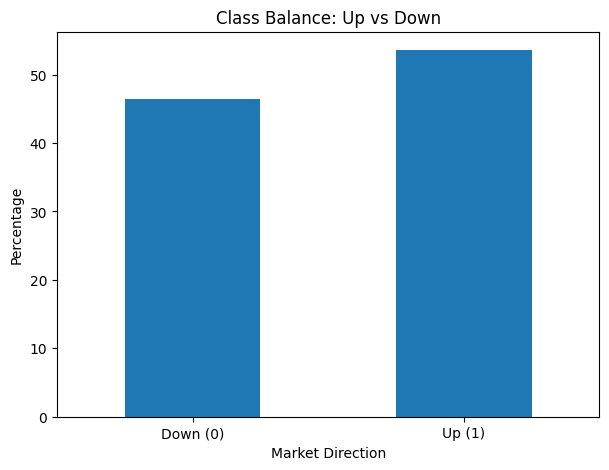

In [ ]:
plt.figure(figsize=(7, 5))

balance_report["Percentage"].plot(kind="bar")

plt.title("Class Balance: Up vs Down")
plt.xlabel("Market Direction")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

## 5. Technical Feature Engineering

We create technical indicators using only information available
on or before the prediction date.

The engineered features include:

- SMA: Simple Moving Average
- Momentum: Difference between the current close and an earlier close
- Rolling Volatility: Recent variability in daily returns
- Daily Return
- Volume Change

In [ ]:
# Simple Moving Average
data["SMA_10"] = data["Close"].rolling(window=10).mean()

# 5-day price momentum
data["Momentum_5"] = data["Close"] - data["Close"].shift(5)

# Daily return
data["Return_1"] = data["Close"].pct_change()

# 10-day rolling volatility
data["Volatility_10"] = (
    data["Return_1"].rolling(window=10).std()
)

# Daily volume change
data["Volume_Change"] = data["Volume"].pct_change()

# Display the engineered features
data[
    [
        "Close",
        "Volume",
        "SMA_10",
        "Momentum_5",
        "Return_1",
        "Volatility_10",
        "Volume_Change",
        "Target"
    ]
].tail(10)

Price,Close,Volume,SMA_10,Momentum_5,Return_1,Volatility_10,Volume_Change,Target
Date,,,,,,,,
2025-12-16,273.864532,37648600,277.495660,-2.563019,0.001824,0.006347,-0.253139,0
2025-12-17,271.102051,50138700,276.267999,-6.921173,-0.010087,0.006569,0.331755,1
2025-12-18,271.451141,51630700,275.419312,-5.824127,0.001288,0.006171,0.029757,1
2025-12-19,272.927124,144632000,274.909702,-4.597473,0.005437,0.006545,1.801279,0
2025-12-22,270.234436,36571800,274.219580,-3.131439,-0.009866,0.007022,-0.747139,1
2025-12-23,271.620667,29642000,273.738892,-2.243866,0.005130,0.007424,-0.189485,1
2025-12-24,273.066711,17910600,273.243240,1.964661,0.005324,0.007375,-0.395770,0
2025-12-26,272.657837,21521800,272.781497,1.206696,-0.001497,0.007368,0.201624,1
2025-12-29,273.016876,23715200,272.330725,0.089752,0.001317,0.007385,0.101915,0


## 6. Prepare the Modeling Dataset

The first few rows contain missing values because the technical
indicators require historical observations.

These rows are removed before model training.

In [ ]:
# Remove rows with missing engineered features
data = data.dropna().copy()

print("Final dataset shape:", data.shape)

print("\nRemaining missing values:")
print(data.isnull().sum())

Final dataset shape: (2000, 12)

Remaining missing values:
Price
Close            0
High             0
Low              0
Open             0
Volume           0
Next_Close       0
Target           0
SMA_10           0
Momentum_5       0
Return_1         0
Volatility_10    0
Volume_Change    0
dtype: int64


In [ ]:
# 80% training, 20% testing
split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

print("Training set:")
print(train_data.index.min(), "to", train_data.index.max())
print("Rows:", len(train_data))

print("\nTesting set:")
print(test_data.index.min(), "to", test_data.index.max())
print("Rows:", len(test_data))

Training set:
2018-01-17 00:00:00 to 2024-05-24 00:00:00
Rows: 1600

Testing set:
2024-05-28 00:00:00 to 2025-12-30 00:00:00
Rows: 400


PAST DATA                         FUTURE DATA
────────────────────────────────────────────────
TRAINING                         TESTING
80%                              20%

2018 ──────────────── 2024 | 2024 ───────── 2025
                           ↑
                     split point

In [ ]:
# Raw OHLCV features
raw_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

# Raw features + technical indicators
engineered_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "SMA_10",
    "Momentum_5",
    "Return_1",
    "Volatility_10",
    "Volume_Change"
]

print("Raw features:")
print(raw_features)

print("\nEngineered features:")
print(engineered_features)

Raw features:
['Open', 'High', 'Low', 'Close', 'Volume']

Engineered features:
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'Momentum_5', 'Return_1', 'Volatility_10', 'Volume_Change']


In [ ]:
y_train = train_data["Target"]
y_test = test_data["Target"]

print("Training target size:", len(y_train))
print("Testing target size:", len(y_test))

Training target size: 1600
Testing target size: 400


## 7. Baseline Models

Before training machine learning models, we establish two simple
baselines:

1. Persistence — predict that tomorrow's direction will match today's.
2. Majority Class — always predict the most common class in the
   training data.

The ML models must be compared against these baselines.


In [ ]:
# Calculate today's market direction
data["Today_Direction"] = np.where(
    data["Close"] > data["Close"].shift(1),
    1,
    0
)

# Persistence predictions on the test set
persistence_predictions = test_data.index.map(
    data["Today_Direction"]
).to_numpy()

persistence_accuracy = accuracy_score(
    y_test,
    persistence_predictions
)

print("Persistence accuracy:",
      round(persistence_accuracy * 100, 2), "%")

Persistence accuracy: 52.25 %


In [ ]:
# Find the most common class in the training set
majority_class = y_train.mode()[0]

# Predict that class for every test observation
majority_predictions = np.full(
    len(y_test),
    majority_class
)

majority_accuracy = accuracy_score(
    y_test,
    majority_predictions
)

print("Majority class:",
      "Up (1)" if majority_class == 1 else "Down (0)")

print("Majority Class accuracy:",
      round(majority_accuracy * 100, 2), "%")

Majority class: Up (1)
Majority Class accuracy: 56.25 %


## 8. Raw OHLCV Model

We first train a Logistic Regression model using only the original
OHLCV features:

- Open
- High
- Low
- Close
- Volume

No technical indicators are included in this model.

The scaler is fitted only on the training data to prevent
information from the test period from influencing the model.

In [ ]:
X_train_raw = train_data[raw_features]
X_test_raw = test_data[raw_features]

print("Raw training shape:", X_train_raw.shape)
print("Raw testing shape:", X_test_raw.shape)

Raw training shape: (1600, 5)
Raw testing shape: (400, 5)


In [ ]:
scaler_raw = StandardScaler()

# Fit ONLY on training data
X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw)

# Use the already-fitted scaler on test data
X_test_raw_scaled = scaler_raw.transform(X_test_raw)

In [ ]:
raw_model = LogisticRegression(max_iter=1000)

raw_model.fit(
    X_train_raw_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
raw_predictions = raw_model.predict(X_test_raw_scaled)

raw_accuracy = accuracy_score(
    y_test,
    raw_predictions
)

print(
    "Raw OHLCV model accuracy:",
    round(raw_accuracy * 100, 2),
    "%"
)

Raw OHLCV model accuracy: 45.0 %


In [ ]:
print(
    classification_report(
        y_test,
        raw_predictions,
        target_names=["Down", "Up"]
    )
)

              precision    recall  f1-score   support

        Down       0.44      1.00      0.61       175
          Up       1.00      0.02      0.04       225

    accuracy                           0.45       400
   macro avg       0.72      0.51      0.33       400
weighted avg       0.76      0.45      0.29       400



## 9. Engineered Feature Model

We now retrain the same Logistic Regression algorithm using the
original OHLCV features together with technical indicators.

This allows a direct comparison between raw market data and
engineered temporal features.

In [ ]:
X_train_engineered = train_data[engineered_features]
X_test_engineered = test_data[engineered_features]

print("Engineered training shape:", X_train_engineered.shape)
print("Engineered testing shape:", X_test_engineered.shape)

Engineered training shape: (1600, 10)
Engineered testing shape: (400, 10)


In [ ]:
scaler_engineered = StandardScaler()

# Fit only on training data
X_train_engineered_scaled = scaler_engineered.fit_transform(
    X_train_engineered
)

# Transform test data using the training-fitted scaler
X_test_engineered_scaled = scaler_engineered.transform(
    X_test_engineered
)

In [ ]:
engineered_model = LogisticRegression(max_iter=1000)

engineered_model.fit(
    X_train_engineered_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
engineered_predictions = engineered_model.predict(
    X_test_engineered_scaled
)

engineered_accuracy = accuracy_score(
    y_test,
    engineered_predictions
)

print(
    "Engineered feature model accuracy:",
    round(engineered_accuracy * 100, 2),
    "%"
)

Engineered feature model accuracy: 48.0 %


In [ ]:
print(
    classification_report(
        y_test,
        engineered_predictions,
        target_names=["Down", "Up"]
    )
)

              precision    recall  f1-score   support

        Down       0.45      0.83      0.58       175
          Up       0.61      0.21      0.31       225

    accuracy                           0.48       400
   macro avg       0.53      0.52      0.45       400
weighted avg       0.54      0.48      0.43       400



## 10. Forward Time-Series Validation

To evaluate the model across multiple chronological periods, we use
TimeSeriesSplit.

Each fold trains on earlier observations and validates on observations
that occur later in time.

No future observations are used to train an earlier validation period.
The scaler is also fitted separately within each training fold.

In [ ]:
# Use the training portion only for forward validation
X_cv = train_data[engineered_features]
y_cv = train_data["Target"]

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_cv), start=1
):

    # Split chronologically
    X_train_fold = X_cv.iloc[train_idx]
    X_val_fold = X_cv.iloc[val_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_val_fold = y_cv.iloc[val_idx]

    # Fit scaler ONLY on this fold's training data
    fold_scaler = StandardScaler()

    X_train_fold_scaled = fold_scaler.fit_transform(
        X_train_fold
    )

    X_val_fold_scaled = fold_scaler.transform(
        X_val_fold
    )

    # Train model
    fold_model = LogisticRegression(max_iter=1000)

    fold_model.fit(
        X_train_fold_scaled,
        y_train_fold
    )

    # Predict validation period
    fold_predictions = fold_model.predict(
        X_val_fold_scaled
    )

    fold_accuracy = accuracy_score(
        y_val_fold,
        fold_predictions
    )

    cv_scores.append(fold_accuracy)

    print(
        f"Fold {fold}: "
        f"{fold_accuracy * 100:.2f}%"
    )

print("\nMean forward validation accuracy:",
      round(np.mean(cv_scores) * 100, 2), "%")

Fold 1: 53.38%
Fold 2: 52.26%
Fold 3: 49.25%
Fold 4: 50.75%
Fold 5: 50.38%

Mean forward validation accuracy: 51.2 %


## 11. Final Model Comparison

We compare four approaches on the same final, unseen test period:

1. Persistence — tomorrow follows today's direction
2. Majority Class — always predicts the dominant training class
3. Raw OHLCV — Logistic Regression using raw market data
4. Engineered Features — Logistic Regression using OHLCV and technical indicators

Directional accuracy is used as the primary evaluation metric.

In [ ]:
# Create the final comparison table
comparison = pd.DataFrame({
    "Approach": [
        "Persistence",
        "Majority Class",
        "Raw OHLCV",
        "Engineered Features"
    ],
    "Directional Accuracy (%)": [
        persistence_accuracy * 100,
        majority_accuracy * 100,
        raw_accuracy * 100,
        engineered_accuracy * 100
    ]
})

comparison["Directional Accuracy (%)"] = (
    comparison["Directional Accuracy (%)"].round(2)
)

comparison

,Approach,Directional Accuracy (%)
0,Persistence,52.25
1,Majority Class,56.25
2,Raw OHLCV,45.00
3,Engineered Features,48.00


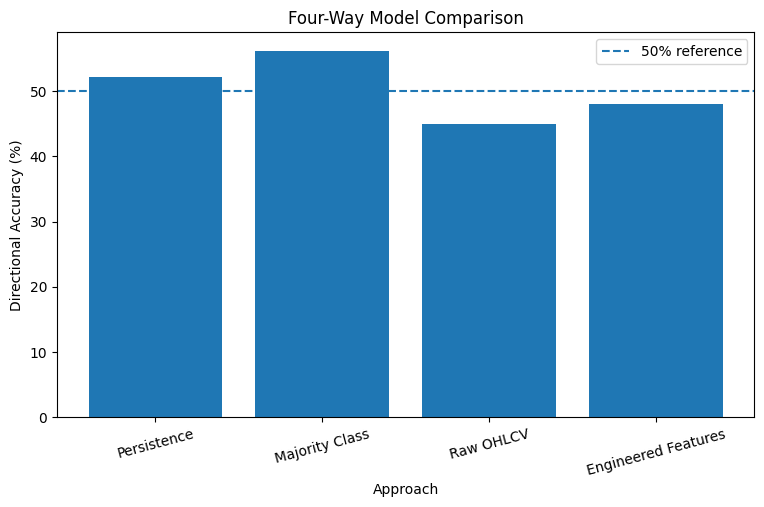

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Approach"],
    comparison["Directional Accuracy (%)"]
)

plt.axhline(
    y=50,
    linestyle="--",
    label="50% reference"
)

plt.ylabel("Directional Accuracy (%)")
plt.xlabel("Approach")
plt.title("Four-Way Model Comparison")
plt.xticks(rotation=15)
plt.legend()

plt.show()

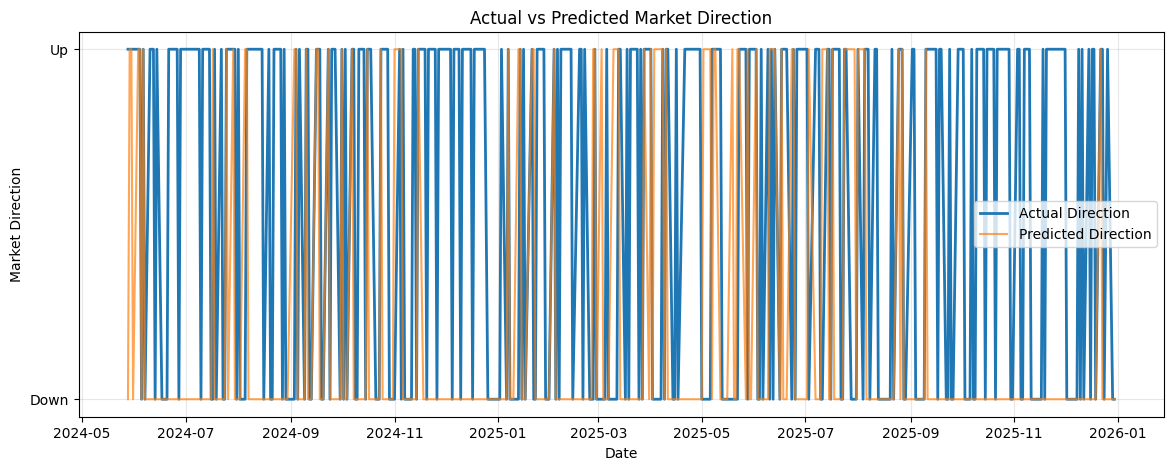

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data.index,
    y_test.values,
    label="Actual Direction",
    linewidth=2
)

plt.plot(
    test_data.index,
    engineered_predictions,
    label="Predicted Direction",
    alpha=0.7
)

plt.yticks([0, 1], ["Down", "Up"])
plt.xlabel("Date")
plt.ylabel("Market Direction")
plt.title("Actual vs Predicted Market Direction")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

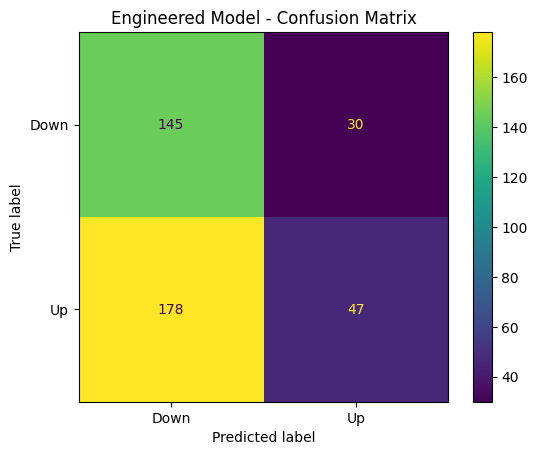

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    engineered_predictions,
    display_labels=["Down", "Up"]
)

plt.title("Engineered Model - Confusion Matrix")
plt.show()

## A confusion matrix for better visual understanding.


##  Conclusion

The model was evaluated using a strict chronological train-test split and forward
time-series validation to avoid future data leakage.

The dataset contained 53.58% Up movements and 46.42% Down movements, showing a
mild class imbalance.

The final test results were:

- Persistence baseline: 52.25%
- Majority Class baseline: 56.25%
- Raw OHLCV Logistic Regression: 45.00%
- Engineered Features Logistic Regression: 48.00%

Adding technical indicators improved the Logistic Regression model from 45.00%
to 48.00%, showing a 3 percentage-point improvement over the raw OHLCV model.
However, the engineered model did not outperform either simple baseline.

Forward TimeSeriesSplit produced a mean validation accuracy of 51.20%, indicating
that the model has limited predictive power across different historical periods.

Overall, the results show that next-day stock-price direction is difficult to
predict using only historical OHLCV data and basic technical indicators.
The experiment demonstrates the importance of leak-free target construction,
time-based validation, baseline comparison, and honest evaluation of financial
machine-learning models.